<a href="https://colab.research.google.com/github/202235415/data202235415/blob/main/%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%EC%9C%B5%ED%95%A9%EB%B3%B4%EC%95%88_202235415_%EA%B9%80%EC%9E%A5%ED%98%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install torch torchvision torchaudio
!pip -q install scikit-learn opencv-python tqdm pandas

In [2]:
import os, random, json, time, copy, math
from pathlib import Path
import numpy as np
import cv2
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt

# ===== CPU 고정 & 재현성 =====
DEVICE = 'cpu'
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(2)  # 환경에 맞게 2~4 정도로 조절

# ===== 경로 설정 (본인 드라이브에 맞게 수정) =====
# 예: /content/drive/MyDrive/malimg (아래 2)에서 마운트 후 사용)
DATA_DIR = "/content/drive/MyDrive/malimg"   # class별 폴더 구조 가정: /malimg/<class>/*.png
CKPT_DIR = "/content/checkpoints"; os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = f"{CKPT_DIR}/vgg16_malimg_gray_cpu.pth"

# ===== 하이퍼파라미터 (CPU 친화) =====
IMG_SIZE   = 224
BATCH_SIZE = 16           # CPU에서는 8~16 권장
NUM_EPOCHS = 3            # 먼저 2~3으로 기준선 확보
LR         = 1e-4
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

# 빠른 점검용 서브셋(없애려면 None)
SUBSET_TOTAL = None  # 예: 1200  # 처음 파이프라인 검증 시 숫자 넣고, 본실험 때 None


In [3]:
from google.colab import drive
drive.mount('/content/drive')
# 마운트 후 DATA_DIR 경로가 실제로 존재하는지 확인
print("DATA_DIR exists:", os.path.exists(DATA_DIR))

Mounted at /content/drive
DATA_DIR exists: True


In [4]:
class ImageFolderGray3(Dataset):
    def __init__(self, root, indices=None, transform=None):
        self.root = Path(root)
        self.samples = []
        classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = {c:i for i,c in enumerate(classes)}
        for c in classes:
            for p in (self.root / c).rglob("*"):
                if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
                    self.samples.append((str(p), self.class_to_idx[c]))
        if indices is not None:
            self.samples = [self.samples[i] for i in indices]
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, y = self.samples[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # (H,W)
        if img is None:
            raise RuntimeError(f"Failed to read {path}")
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        img = np.stack([img, img, img], axis=2)        # Gray 3채널 복제
        if self.transform:
            img = self.transform(img)
        return img, y, path

def make_splits(n, val_ratio=0.15, test_ratio=0.15):
    idx = np.arange(n); np.random.shuffle(idx)
    n_val = int(n * val_ratio); n_test = int(n * test_ratio)
    val_idx = idx[:n_val]
    test_idx = idx[n_val:n_val+n_test]
    train_idx = idx[n_val+n_test:]
    return train_idx, val_idx, test_idx

# 원본 풀 리스트
_tmp = ImageFolderGray3(DATA_DIR, indices=None, transform=None)
all_len = len(_tmp)
if SUBSET_TOTAL is not None:
    SUBSET_TOTAL = min(SUBSET_TOTAL, all_len)
    base_idx = np.arange(all_len)
    np.random.shuffle(base_idx)
    base_idx = base_idx[:SUBSET_TOTAL]
    _tmp.samples = [ _tmp.samples[i] for i in base_idx ]
    print(f"[Subset] use {len(_tmp)} samples out of {all_len}")
else:
    print(f"[Full] total samples: {all_len}")

train_idx, val_idx, test_idx = make_splits(len(_tmp), VAL_SPLIT, TEST_SPLIT)

# 변환
train_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_ds = ImageFolderGray3(DATA_DIR, [i for i in train_idx], transform=train_tf)
val_ds   = ImageFolderGray3(DATA_DIR, [i for i in val_idx],   transform=eval_tf)
test_ds  = ImageFolderGray3(DATA_DIR, [i for i in test_idx],  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

NUM_CLASSES = len(train_ds.class_to_idx)
CLASS_NAMES = [None]*NUM_CLASSES
for c, i in train_ds.class_to_idx.items():
    CLASS_NAMES[i] = c
print(f"Total={len(train_ds)+len(val_ds)+len(test_ds)} | train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")
print("Classes:", CLASS_NAMES)


[Full] total samples: 9339
Total=9339 | train=6539 val=1400 test=1400
Classes: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']


In [5]:
def build_model(num_classes):
    # torchvision 버전에 따라 weights 인자가 다를 수 있어 try/except
    try:
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    except:
        model = models.vgg16(pretrained=True)
    # features freeze (필요 시 해제 가능)
    for p in model.features.parameters():
        p.requires_grad = False
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model

model = build_model(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 113MB/s]


In [6]:
import copy, numpy as np, torch, torch.nn as nn
from tqdm import tqdm
import os

# 1) 백본(합성곱+avgpool+Flatten+classifier[:-1]) 구성
feat_model = copy.deepcopy(model).to(DEVICE)
feat_model.eval()
backbone = nn.Sequential(
    feat_model.features,
    feat_model.avgpool,
    nn.Flatten(),
    *list(feat_model.classifier.children())[:-1]  # 마지막 FC 직전까지
).to(DEVICE)
for p in backbone.parameters(): p.requires_grad = False

def extract_features(loader, split_name):
    X_list, Y_list = [], []
    with torch.no_grad():
        for x, y, _ in tqdm(loader, desc=f"Extract {split_name}"):
            x = x.to(DEVICE)
            f = backbone(x)              # (B, 4096)
            X_list.append(f.cpu().numpy()); Y_list.append(np.array(y))
    X = np.concatenate(X_list, axis=0); Y = np.concatenate(Y_list, axis=0)
    return X, Y

Xtr, Ytr = extract_features(train_loader, "train")
Xva, Yva = extract_features(val_loader,   "val")
Xte, Yte = extract_features(test_loader,  "test")



Extract test: 100%|██████████| 88/88 [21:43<00:00, 14.81s/it]


In [7]:
# ⛑ evaluate 함수 재정의 (간단/자급자족 버전)
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

def evaluate(loader, model, device=DEVICE):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(device)
            y = torch.as_tensor(y, device=device)
            out = model(x)
            pred = out.argmax(1)
            ys.append(y.cpu().numpy())
            preds.append(pred.cpu().numpy())
    ys = np.concatenate(ys); preds = np.concatenate(preds)
    acc = accuracy_score(ys, preds)
    f1  = f1_score(ys, preds, average='macro')
    return acc, f1


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import joblib

# 표준화
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr); Xva_s = scaler.transform(Xva); Xte_s = scaler.transform(Xte)

# 로지스틱 회귀(멀티클래스)
clf = LogisticRegression(
    penalty="l2", C=1.0, solver="lbfgs", multi_class="multinomial",
    max_iter=300, n_jobs=1, class_weight=None  # 불균형 심하면 'balanced'
)
clf.fit(Xtr_s, Ytr)

# 검증/테스트 빠른 확인
pred_va = clf.predict(Xva_s); pred_te = clf.predict(Xte_s)
print("[VAL]  acc=", accuracy_score(Yva, pred_va), "f1=", f1_score(Yva, pred_va, average="macro"))
print("[TEST quick] acc=", accuracy_score(Yte, pred_te), "f1=", f1_score(Yte, pred_te, average="macro"))

# 학습된 계수 → VGG 마지막 FC에 이식
W = clf.coef_.astype(np.float32)      # (num_classes, 4096)
b = clf.intercept_.astype(np.float32) # (num_classes,)
fc = nn.Linear(W.shape[1], W.shape[0])
with torch.no_grad():
    fc.weight.copy_(torch.from_numpy(W))
    fc.bias.copy_(torch.from_numpy(b))
model.classifier[6] = fc.to(DEVICE)

# 최종 테스트(원래 evaluate 함수 사용) + 체크포인트 저장
test_acc, test_f1 = evaluate(test_loader, model)
print(f"[Test Baseline via cached feats] acc={test_acc:.4f} f1={test_f1:.4f}")

os.makedirs(CKPT_DIR, exist_ok=True)
torch.save(model.state_dict(), CKPT_PATH)
joblib.dump(scaler, f"{CKPT_DIR}/std_scaler.pkl")
print("Saved:", CKPT_PATH)

import torch.nn as nn

def disable_inplace_relu(module):
    for m in module.modules():
        if isinstance(m, nn.ReLU):
            m.inplace = False

disable_inplace_relu(model)   # ← VGG 전체에서 in-place ReLU 끄기


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[VAL]  acc= 0.9764285714285714 f1= 0.9357234291824436
[TEST quick] acc= 0.9835714285714285 f1= 0.9452546028693878
[Test Baseline via cached feats] acc=0.6307 f1=0.4163
Saved: /content/checkpoints/vgg16_malimg_gray_cpu.pth


In [33]:
import torch, torch.nn as nn

def disable_inplace_relu(m):
    for mm in m.modules():
        if isinstance(mm, nn.ReLU):
            mm.inplace = False

disable_inplace_relu(model)  # ← 모델 로드 직후 1번만
model.eval()
torch.set_grad_enabled(True)


torch.autograd.grad_mode.set_grad_enabled(mode=True)

In [34]:
# ===== CLEAN Grad-CAM (Conv 모듈에 직접 훅 + 텐서 grad-hook) =====
import torch, cv2

class GradCAM:
    """
    - target_module: 마지막 Conv 모듈(예: model.features[28]) '객체'를 넘김
    - forward: target_module의 출력을 저장하고, 그 텐서에 grad-hook을 직접 등록
    - backward: score.backward() 1번 → grad-hook이 dA를 채움
    - ReLU(inplace=False) 필수 (GC-1에서 이미 처리)
    """
    def __init__(self, model, target_module):
        self.model = model
        self.target_module = target_module
        self.activations = None
        self.gradients  = None

        def fwd_hook(mod, inp, out):
            # 그래프 보존: detach/clone 하지 않음
            self.activations = out
            self.gradients   = None
            out.retain_grad()                   # 비-리프 텐서라도 .grad 저장
            out.register_hook(self._save_grad)  # 텐서에 직접 hook
        self._fh = self.target_module.register_forward_hook(fwd_hook)

        self._prev_requires = None  # freeze 모델에서도 grad 흐르게 잠깐 켰다가 복구

    def _save_grad(self, g):
        self.gradients = g

    def remove_hooks(self):
        try: self._fh.remove()
        except: pass

    def _enable_feature_grads(self, flag=True):
        # VGG: model.features에 한정
        if self._prev_requires is None:
            self._prev_requires = [p.requires_grad for p in self.model.features.parameters()]
        for p in self.model.features.parameters():
            p.requires_grad_(flag)

    def _restore_feature_grads(self):
        if self._prev_requires is not None:
            for p, req in zip(self.model.features.parameters(), self._prev_requires):
                p.requires_grad_(req)
            self._prev_requires = None

    @torch.no_grad()
    def _resize_to_input(self, cam_t, x):
        # cam_t: (h,w) tensor, x: (B,C,H,W)
        cam = cam_t.detach().cpu().numpy()
        return cv2.resize(cam, (x.size(3), x.size(2)))

    def generate(self, x, class_idx=None):
        """
        x: (1,C,H,W) — 절대 no_grad로 감싸지 말 것!
        return: cam (H,W numpy[0~1]), pred_idx, probs(np.array)
        """
        # grad 필요
        torch.set_grad_enabled(True)
        self._enable_feature_grads(True)
        self.model.zero_grad(set_to_none=True)

        # forward (이때 forward hook이 activations를 채우고 텐서 grad-hook 등록)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        score = out[0, class_idx]

        # backward 1번 → 텐서 grad-hook이 self.gradients 채움
        score.backward(retain_graph=True)

        # 안전 체크
        assert self.activations is not None, "forward hook didn't fire (target_module 확인)"
        assert self.gradients  is not None,  "tensor grad hook didn't fire (no_grad/순서 확인)"

        # A: (K,h,w), dA: (K,h,w)
        A  = self.activations[0]
        dA = self.gradients[0]

        # Grad-CAM: 채널별 평균 기울기 가중치
        weights = dA.view(dA.size(0), -1).mean(dim=1)          # (K,)
        cam_t   = (weights[:, None, None] * A).sum(0)          # (h,w)
        cam_t   = torch.relu(cam_t)
        cam_t   = (cam_t - cam_t.min()) / (cam_t.max() - cam_t.min() + 1e-6)

        cam = self._resize_to_input(cam_t, x)                  # (H,W) numpy
        probs = out.softmax(1).detach().cpu().numpy()[0]

        self._restore_feature_grads()
        return cam, class_idx, probs
# ================================================================



In [35]:
# VGG16의 마지막 Conv 찾기 (features에서 마지막 Conv2d)
last_conv = None
for m in reversed(list(model.features.children())):
    if isinstance(m, nn.Conv2d):
        last_conv = m
        break
assert last_conv is not None, "Conv2d target not found in model.features"

# 혹시나 인스턴스가 남아있다면 정리 후 새로 생성
try: gradcam.remove_hooks()
except: pass

gradcam = GradCAM(model, target_module=last_conv)

# 훅 발화 점검 (1회)
_fired = {"ok": False}
def _probe(mod, inp, out):
    _fired["ok"] = True
tap = last_conv.register_forward_hook(_probe)
_ = model(next(iter(test_loader))[0][:1].to(next(model.parameters()).device))
tap.remove()
print("forward at last_conv fired?", _fired["ok"])


forward at last_conv fired? True


In [36]:
x0, y0, _ = test_ds[0]
x1 = x0.unsqueeze(0).to(next(model.parameters()).device)

cam0, cidx, prob = gradcam.generate(x1)   # 절대 no_grad로 감싸지 말 것
print("Pred:", CLASS_NAMES[cidx], f"prob={prob[cidx]:.3f}", "| True:", CLASS_NAMES[y0])



Pred: Allaple.A prob=0.765 | True: Allaple.L


In [38]:
import numpy as np, torch

def shift_cam(cam, dx=0, dy=0):
    H,W=cam.shape; M=np.float32([[1,0,dx],[0,1,dy]])
    s=cv2.warpAffine(cam,M,(W,H),flags=cv2.INTER_LINEAR,borderMode=cv2.BORDER_CONSTANT,borderValue=0)
    s=(s-s.min())/(s.max()-s.min()+1e-6); return s

def rotate_cam(cam, angle=0):
    H,W=cam.shape; center=(W//2,H//2)
    M=cv2.getRotationMatrix2D(center,angle,1.0)
    r=cv2.warpAffine(cam,M,(W,H),flags=cv2.INTER_LINEAR,borderMode=cv2.BORDER_CONSTANT,borderValue=0)
    r=(r-r.min())/(r.max()-r.min()+1e-6); return r

def apply_mask_to_input(x_tensor, cam, mode='mul'):
    cam_t=torch.from_numpy(cam).float().to(x_tensor.device)[None,None,...]
    cam_t=cam_t.expand(-1,x_tensor.size(1),-1,-1)
    if mode=='mul': x_new=x_tensor*(0.5+0.5*cam_t)
    elif mode=='inv': x_new=x_tensor*(1.0-0.8*cam_t)
    else: raise ValueError
    return x_new

def denorm_to_uint8(x3hw):
    x=x3hw.clone().detach().cpu()*0.5+0.5; x=x.clamp(0,1).numpy()
    return (x*255).astype(np.uint8).transpose(1,2,0)


In [39]:
x0, y0, _ = test_ds[0]
x1 = x0.unsqueeze(0).to(DEVICE)

cam0, cidx, prob = gradcam.generate(x1)   # ← no torch.no_grad()
print("Pred:", CLASS_NAMES[cidx], f"prob={prob[cidx]:.3f}", "| True:", CLASS_NAMES[y0])

Pred: Allaple.A prob=0.765 | True: Allaple.L


Pred: Allaple.A prob=0.765 | True: Allaple.L
Shift(+20,0)+mul → Pred: Allaple.A prob=0.741


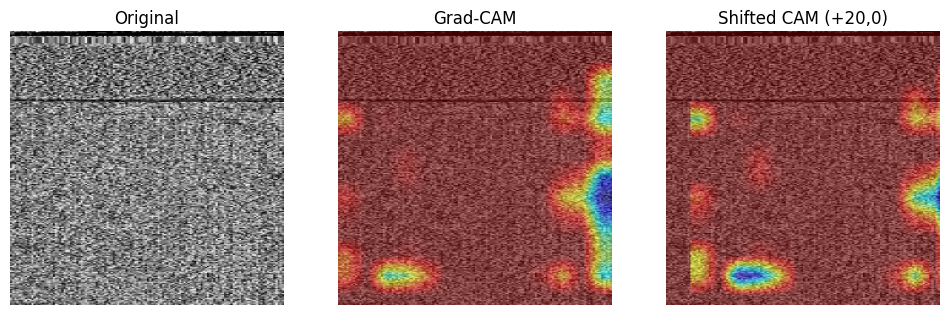

In [40]:
import matplotlib.pyplot as plt

x0,y0,p0=test_ds[0]
x1=x0.unsqueeze(0).to(DEVICE)
cam0,cidx,prob=gradcam.generate(x1)   # no torch.no_grad()

print("Pred:", CLASS_NAMES[cidx], f"prob={prob[cidx]:.3f}", "| True:", CLASS_NAMES[y0])

cam_shift=shift_cam(cam0, dx=+20, dy=0)
x_mul=apply_mask_to_input(x1, cam_shift, mode='mul')
with torch.no_grad():
    out=model(x_mul); pred2=out.argmax(1).item(); conf2=out.softmax(1)[0,pred2].item()
print("Shift(+20,0)+mul → Pred:", CLASS_NAMES[pred2], f"prob={conf2:.3f}")

orig=denorm_to_uint8(x0)
ov=cv2.applyColorMap((cam0*255).astype(np.uint8), cv2.COLORMAP_JET)
blend=cv2.addWeighted(orig,0.5,ov,0.5,0)
ov_s=cv2.applyColorMap((cam_shift*255).astype(np.uint8), cv2.COLORMAP_JET)
blend_s=cv2.addWeighted(orig,0.5,ov_s,0.5,0)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(orig); plt.axis('off')
plt.subplot(1,3,2); plt.title("Grad-CAM"); plt.imshow(blend); plt.axis('off')
plt.subplot(1,3,3); plt.title("Shifted CAM (+20,0)"); plt.imshow(blend_s); plt.axis('off')
plt.show()



In [41]:
from collections import defaultdict
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import torch

def evaluate_with_cam_perturbations(
    loader, model, gradcam,
    shifts=[-20, -10, 0, 10, 20],
    angles=[0, 10, -10, 20, -20],
    mode='mul',
    max_batches=None,
    show_pbar=True,
):
    """
    - 샘플별 CAM은 어쩔 수 없이 1회(forward+backward) 필요.
    - 그러나 CAM 변형(shift/rotate) 이후의 추론들은 한 번에 묶어 '1회 forward'로 처리 → 크게 빨라짐.
    - 반환: summary(list[ (tag, val, acc, f1, mean_delta_prob) ])
    """
    model.eval()

    # 정리용 컨테이너
    results = {}
    conditions = []
    for dx in shifts:        conditions.append(("shift", dx))
    for ang in angles:
        if ang != 0:         conditions.append(("rot", ang))

    results = {cond: {"y": [], "pred": []} for cond in conditions}
    base     = {"y": [], "pred": [], "prob": []}
    delta_scores = defaultdict(list)  # |p_base - p_cond|

    it = enumerate(loader)
    if show_pbar:
        it = tqdm(loader, desc="Perturbation Eval (vectorized)", total=len(loader))

    for bi, (x, y, paths) in enumerate(it if show_pbar else enumerate(loader)):
        if max_batches is not None and bi >= max_batches:
            break

        x = x.to(DEVICE)
        y = torch.as_tensor(y, device=DEVICE)

        # 1) 베이스 예측 (배치 한 번에)
        with torch.no_grad():
            out_base = model(x)
            base_pred = out_base.argmax(1)
            base_prob = out_base.softmax(1).max(1).values  # per-sample max prob
        base["y"].extend(y.cpu().numpy())
        base["pred"].extend(base_pred.cpu().numpy())
        base["prob"].extend(base_prob.cpu().numpy())

        # 2) 각 샘플별 CAM 생성 + 모든 조건 입력을 모아 '한 번의 forward'로
        for i in range(x.size(0)):
            xi = x[i:i+1]  # (1,3,H,W)

            # (필수) no_grad 없이 CAM 생성 (forward+backward)
            cam_i, _, _ = gradcam.generate(xi, class_idx=None)

            # 조건별 입력 만들기
            xi_variants = []
            cond_tags   = []

            # shifts
            for dx in shifts:
                cam_s = shift_cam(cam_i, dx=dx, dy=0)
                xi_variants.append(apply_mask_to_input(xi, cam_s, mode=mode))
                cond_tags.append(("shift", dx))

            # rotations(0은 스킵)
            for ang in angles:
                if ang == 0:
                    continue
                cam_r = rotate_cam(cam_i, angle=ang)
                xi_variants.append(apply_mask_to_input(xi, cam_r, mode=mode))
                cond_tags.append(("rot", ang))

            if not xi_variants:
                continue

            batch_variants = torch.cat(xi_variants, dim=0)  # (Ncond, 3, H, W)

            # 3) 변형 입력들을 '한 번에' forward
            with torch.no_grad():
                out_var = model(batch_variants)
                preds_batch = out_var.argmax(1).cpu().numpy().tolist()
                probs_batch = out_var.softmax(1).max(1).values.cpu().numpy().tolist()

            # 4) 결과 누적
            y_true_i = int(y[i].cpu().item())
            p_base_i = float(base_prob[i].cpu().item())
            for (tag, val), pred_s, prob_s in zip(cond_tags, preds_batch, probs_batch):
                results[(tag, val)]["y"].append(y_true_i)
                results[(tag, val)]["pred"].append(int(pred_s))
                delta_scores[(tag, val)].append(abs(p_base_i - float(prob_s)))

    # 5) 요약
    base_acc = accuracy_score(base["y"], base["pred"])
    base_f1  = f1_score(base["y"], base["pred"], average='macro')
    summary = [("baseline", 0, base_acc, base_f1, 0.0)]

    for cond, data in results.items():
        acc = accuracy_score(data["y"], data["pred"]) if data["y"] else 0.0
        f1  = f1_score(data["y"], data["pred"], average='macro') if data["y"] else 0.0
        md  = float(np.mean(delta_scores[cond])) if len(delta_scores[cond])>0 else 0.0
        tag, val = cond
        summary.append((tag, val, acc, f1, md))

    def sort_key(t):
        tag, val, *_ = t
        return (0 if tag=="baseline" else (1 if tag=="shift" else 2), val)
    summary = sorted(summary, key=sort_key)
    return summary


In [42]:
#가벼운 실험
summary_mul = evaluate_with_cam_perturbations(
    test_loader, model, gradcam,
    shifts=[-20, 0, 20],   # 간격 큼
    angles=[0],            # 회전 OFF (속도↑)
    mode='mul',
    max_batches=3          # 배치 3개만
)
for s in summary_mul: print(s)

Perturbation Eval (vectorized):   3%|▎         | 3/88 [04:21<2:03:15, 87.00s/it]

('baseline', 0, 0.7291666666666666, 0.5958049886621315, 0.0)
('shift', -20, 0.5416666666666666, 0.2770800627943485, 0.0596191231161356)
('shift', 0, 0.5625, 0.35766614338042907, 0.05033735744655132)
('shift', 20, 0.5625, 0.35766614338042907, 0.05319388769567013)


In [46]:
# (1) mul + shift만
summary_mul_shift = evaluate_with_cam_perturbations(
    test_loader, model, gradcam,
    shifts=[-20,-10,0,10,20],
    angles=[0],
    mode='mul',
    max_batches=44
)

# (2) mul + rot만
summary_mul_rot = evaluate_with_cam_perturbations(
    test_loader, model, gradcam,
    shifts=[0],         # mask-only만
    angles=[10,-10],
    mode='mul',
    max_batches=44
)

# (3) inv도 (1)(2)처럼 분리


Perturbation Eval (vectorized):  50%|█████     | 44/88 [1:01:48<1:01:48, 84.29s/it]


In [47]:
for s in summary_mul_shift: print(s)
for s in summary_mul_rot: print(s)

('baseline', 0, 0.6264204545454546, 0.4130301315885215, 0.0)
('shift', -20, 0.5241477272727273, 0.3068695554177242, 0.06268650225617668)
('shift', -10, 0.6079545454545454, 0.35698108646102367, 0.06578116411004555)
('shift', 0, 0.5269886363636364, 0.31152929872266133, 0.05730855431069027)
('shift', 10, 0.5269886363636364, 0.31087976255577854, 0.0623426299161193)
('shift', 20, 0.5255681818181818, 0.3082068671983127, 0.06485149116170677)
('baseline', 0, 0.6264204545454546, 0.4130301315885215, 0.0)
('shift', 0, 0.5269886363636364, 0.31152929872266133, 0.057308551580221814)
('rot', -10, 0.609375, 0.3585785224359734, 0.0649659010920335)
('rot', 10, 0.5255681818181818, 0.3133859626966324, 0.061908605000512165)


In [44]:
# (1) mul + shift만
summary_inv_shift = evaluate_with_cam_perturbations(
    test_loader, model, gradcam,
    shifts=[-20,-10,0,10,20],
    angles=[0],
    mode='inv',
    max_batches=44
)

# (2) mul + rot만
summary_inv_rot = evaluate_with_cam_perturbations(
    test_loader, model, gradcam,
    shifts=[0],         # mask-only만
    angles=[10,-10],
    mode='inv',
    max_batches=44
)

# (3) inv도 (1)(2)처럼 분리

Perturbation Eval (vectorized):  50%|█████     | 44/88 [1:01:11<1:01:11, 83.45s/it]


In [45]:
for s in summary_inv_shift: print(s)
for s in summary_inv_rot: print(s)

('baseline', 0, 0.6264204545454546, 0.4130301315885215, 0.0)
('shift', -20, 0.6150568181818182, 0.3935327710866844, 0.03592989437112754)
('shift', -10, 0.6178977272727273, 0.3934865411151465, 0.029549577019431374)
('shift', 0, 0.6235795454545454, 0.40515894660789814, 0.03209882096218115)
('shift', 10, 0.625, 0.41529681703824456, 0.0357003711079332)
('shift', 20, 0.6207386363636364, 0.403483001320453, 0.04157070989127864)
('baseline', 0, 0.6264204545454546, 0.4130301315885215, 0.0)
('shift', 0, 0.6235795454545454, 0.40515894660789814, 0.03209882506846704)
('rot', -10, 0.6164772727272727, 0.4011565929192916, 0.03212702407670969)
('rot', 10, 0.625, 0.41799333654481363, 0.02410561159591783)


In [48]:
import pandas as pd

def to_df(summary, mode):
    # summary: list of (tag, val, acc, f1, mdp)
    df = pd.DataFrame(summary, columns=["tag","val","acc","f1","mdp"])
    df["mode"] = mode  # 'mul' or 'inv'
    return df

# 예) 분할 실행한 결과들을 합치기
df_all = pd.concat([
    to_df(summary_mul_shift, "mul"),
    to_df(summary_mul_rot,   "mul"),
    to_df(summary_inv_shift, "inv"),
    to_df(summary_inv_rot,   "inv"),
], ignore_index=True)

# 필요시 baseline 중복 정리(한 번만 남기기)
df_all = df_all.drop_duplicates(subset=["mode","tag","val"])

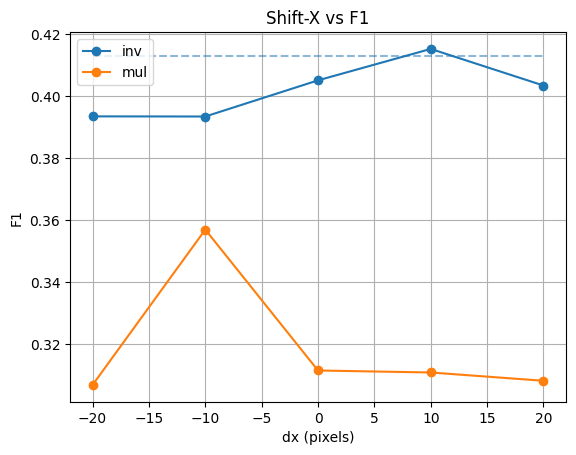

In [49]:
import matplotlib.pyplot as plt

def plot_shift(df, metric="f1"):
    d = df[df["tag"].isin(["baseline","shift_x","shift"])]  # 함수 버전에 따라 tag가 shift_x 또는 shift
    base = d[d["tag"]=="baseline"].groupby("mode")[metric].mean()  # 기준선

    for mode, g in d[d["tag"]!="baseline"].groupby("mode"):
        g = g.sort_values("val")
        plt.plot(g["val"], g[metric], marker="o", label=f"{mode}")

        # baseline 수평선
        if mode in base.index:
            plt.hlines(base[mode], xmin=g["val"].min(), xmax=g["val"].max(),
                       linestyles="dashed", alpha=.3)

    plt.title(f"Shift-X vs {metric.upper()}")
    plt.xlabel("dx (pixels)"); plt.ylabel(metric.upper()); plt.legend(); plt.grid(True)
    plt.show()

plot_shift(df_all, metric="f1")


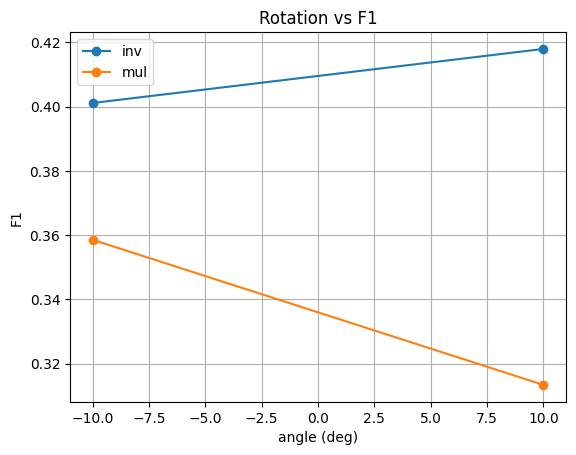

In [50]:
def plot_rot(df, metric="f1"):
    d = df[df["tag"].isin(["rot"])]
    for mode, g in d.groupby("mode"):
        g = g.sort_values("val")
        plt.plot(g["val"], g[metric], marker="o", label=f"{mode}")
    plt.title(f"Rotation vs {metric.upper()}")
    plt.xlabel("angle (deg)"); plt.ylabel(metric.upper()); plt.legend(); plt.grid(True)
    plt.show()

plot_rot(df_all, metric="f1")


In [51]:
import pandas as pd

def summarize_delta(df, metric="f1"):
    base = df[df.tag=="baseline"].groupby("mode")[metric].mean().to_dict()
    rows=[]
    for (mode, tag), g in df[df.tag!="baseline"].groupby(["mode","tag"]):
        for _,r in g.iterrows():
            rows.append({
                "mode": mode, "tag": tag, "val": r["val"],
                metric: r[metric], f"Δ{metric}": r[metric]-base[mode]
            })
    out = pd.DataFrame(rows).sort_values(["mode","tag","val"])
    return out

delta = summarize_delta(df_all, metric="f1")
display(delta)  # 표 그대로 보고서/부록에


,mode,tag,val,f1,Δf1
0,inv,rot,-10,0.401157,-0.011874
1,inv,rot,10,0.417993,0.004963
2,inv,shift,-20,0.393533,-0.019497
3,inv,shift,-10,0.393487,-0.019544
4,inv,shift,0,0.405159,-0.007871
5,inv,shift,10,0.415297,0.002267
6,inv,shift,20,0.403483,-0.009547
7,mul,rot,-10,0.358579,-0.054452
8,mul,rot,10,0.313386,-0.099644
9,mul,shift,-20,0.306870,-0.106161


In [69]:
import numpy as np
import pandas as pd

def _find_val_col(df: pd.DataFrame):
    for cand in ["val","value","dx","angle","cond_val"]:
        if cand in df.columns: return cand
    num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    for drop in ["acc","f1","mdp"]:
        if drop in num_cols: num_cols.remove(drop)
    for drop in ["mode","tag"]:
        if drop in num_cols:
            try: num_cols.remove(drop)
            except: pass
    return num_cols[0] if num_cols else None

def make_table_sep_baseline(df_all: pd.DataFrame, target="shift"):
    """
    shift/rotate 별 표 생성:
      - baseline은 value 칸을 NaN으로 두고 'kind'='baseline'
      - value가 0인 조건은 'kind'='shift0' 또는 'rot0'
      - 나머지는 'kind'='shift' 또는 'rot'
      - Δacc/Δf1/Δmdp는 baseline 기준
      - label 컬럼으로 보기 쉽게 표시 ('baseline', 'shift=+10' 등)
    """
    d = df_all.copy()
    d["tag"] = d["tag"].replace({"shift_x":"shift"})
    vcol = _find_val_col(d)
    if vcol is None:
        raise KeyError("변형 강도 컬럼을 찾지 못했습니다. df_all.columns를 확인하세요.")

    # 모드별 baseline 성능
    base = (d[d["tag"]=="baseline"]
            .groupby("mode")[["acc","f1","mdp"]].mean().to_dict())

    # 대상 조건만
    cond = d[d["tag"]==target][["mode", vcol, "acc","f1","mdp"]].copy()
    # condition kind/label
    def _kind(val):
        if float(val)==0.0: return f"{target}0"
        return target
    cond["_kind"] = cond[vcol].apply(_kind)
    def _label(val):
        s = f"{int(val):+d}" if abs(val-round(val))<1e-6 else f"{val:+.2f}"
        return f"{target}={s}"
    cond["_label"] = cond[vcol].apply(_label)

    # baseline 행 추가 (value는 NaN으로 비워서 구분)
    base_rows=[]
    for m in sorted(d["mode"].unique()):
        if m in base["acc"]:
            base_rows.append({
                "mode": m, vcol: np.nan,
                "acc":  base["acc"][m],
                "f1":   base["f1"][m],
                "mdp":  base["mdp"].get(m, 0.0),
                "_kind":"baseline",
                "_label":"baseline"
            })
    base_df = pd.DataFrame(base_rows)

    out = pd.concat([cond, base_df], ignore_index=True)

    # Δ 계산(항상 baseline 기준)
    out["Δacc"] = out.apply(lambda r: r["acc"] - base["acc"].get(r["mode"], np.nan), axis=1)
    out["Δf1"]  = out.apply(lambda r: r["f1"]  - base["f1"].get(r["mode"], np.nan),  axis=1)
    out["Δmdp"] = out.apply(lambda r: r["mdp"] - base["mdp"].get(r["mode"], 0.0),    axis=1)

    # 정렬: baseline → 0 → 나머지(값 오름차순)
    order_map = {"baseline":0, f"{target}0":1, target:2}
    out["_order"] = out["_kind"].map(order_map).fillna(9)
    out = out.sort_values(["mode","_order", vcol], kind="mergesort")

    # 보기 좋은 컬럼명/순서
    nice_val = "dx" if target=="shift" else "angle"
    out = (out.rename(columns={vcol: nice_val, "_kind":"kind", "_label":"label"})
             [["mode","kind","label", nice_val, "acc","f1","Δacc","Δf1","mdp","Δmdp"]]
             .reset_index(drop=True))
    return out

def style_table(tbl):
    sty = (tbl.style
           .format({"acc":"{:.3f}","f1":"{:.3f}","Δacc":"{:+.3f}","Δf1":"{:+.3f}",
                    "mdp":"{:.4f}","Δmdp":"{:+.4f}"})
           .apply(lambda s: ["font-weight:bold; background:#FFF3CD" if k=="baseline" else ""
                            for k in tbl["kind"]], axis=0))
    return sty

display(style_table(tbl_shift))
display(style_table(tbl_rot))





,mode,kind,label,dx,acc,f1,Δacc,Δf1,mdp,Δmdp
0,inv,baseline,baseline,nan,0.626,0.413,+0.000,+0.000,0.0000,+0.0000
1,inv,shift0,shift=+0,0.000000,0.624,0.405,-0.003,-0.008,0.0321,+0.0321
2,inv,shift,shift=-20,-20.000000,0.615,0.394,-0.011,-0.019,0.0359,+0.0359
3,inv,shift,shift=-10,-10.000000,0.618,0.393,-0.009,-0.020,0.0295,+0.0295
4,inv,shift,shift=+10,10.000000,0.625,0.415,-0.001,+0.002,0.0357,+0.0357
5,inv,shift,shift=+20,20.000000,0.621,0.403,-0.006,-0.010,0.0416,+0.0416
6,mul,baseline,baseline,nan,0.626,0.413,+0.000,+0.000,0.0000,+0.0000
7,mul,shift0,shift=+0,0.000000,0.527,0.312,-0.099,-0.102,0.0573,+0.0573
8,mul,shift,shift=-20,-20.000000,0.524,0.307,-0.102,-0.106,0.0627,+0.0627
9,mul,shift,shift=-10,-10.000000,0.608,0.357,-0.018,-0.056,0.0658,+0.0658


,mode,kind,label,angle,acc,f1,Δacc,Δf1,mdp,Δmdp
0,inv,baseline,baseline,nan,0.626,0.413,+0.000,+0.000,0.0000,+0.0000
1,inv,rot,rot=-10,-10.000000,0.616,0.401,-0.010,-0.012,0.0321,+0.0321
2,inv,rot,rot=+10,10.000000,0.625,0.418,-0.001,+0.005,0.0241,+0.0241
3,mul,baseline,baseline,nan,0.626,0.413,+0.000,+0.000,0.0000,+0.0000
4,mul,rot,rot=-10,-10.000000,0.609,0.359,-0.017,-0.054,0.0650,+0.0650
5,mul,rot,rot=+10,10.000000,0.526,0.313,-0.101,-0.100,0.0619,+0.0619


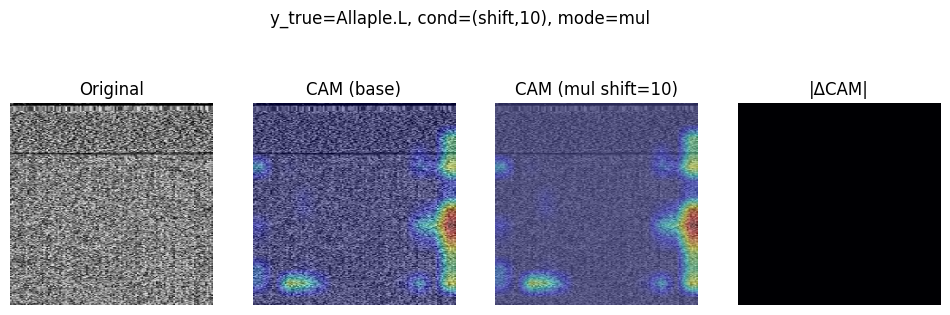

In [56]:
import numpy as np, torch, matplotlib.pyplot as plt

# --- 유틸: 텐서→이미지, 오버레이 ---
def denorm01(x):  # x: (1,C,H,W) normalized
    # 네 전처리에 맞게 수정. 아래는 (mean=0.5, std=0.5) 가정 예시
    x = x.clone().detach()
    x = x*0.5 + 0.5
    return x.clamp(0,1)[0].permute(1,2,0).cpu().numpy()

def overlay(img01, cam01, alpha=0.35):
    if img01.ndim==2: img01 = np.stack([img01]*3, -1)
    cam = plt.cm.jet(cam01)[...,:3]
    return (1-alpha)*img01 + alpha*cam

def cam_diff(c0, c1):
    d = np.abs(c1 - c0)
    if d.max()>0: d = d/(d.max()+1e-6)
    return d

# --- 핵심: 한 샘플의 CAM 변화 시각화 ---
def show_cam_change(xi, y_true, gradcam, mode=("mul"), cond=("shift",10),
                    apply_mask_to_input=None, shift_cam=None, rotate_cam=None,
                    figsize=(12,4)):
    """
    xi: (1,C,H,W) tensor on DEVICE
    cond: ("shift", dx) or ("rot", angle)
    """
    assert apply_mask_to_input and shift_cam and rotate_cam, "필요 유틸 함수를 넘겨주세요"

    # 1) 원본 CAM
    cam0, _, _ = gradcam.generate(xi)

    # 2) CAM 변형 만들기
    tag, val = cond
    if tag in ("shift","shift_x"):   cam_p = shift_cam(cam0, dx=val, dy=0)
    elif tag=="rot":                 cam_p = rotate_cam(cam0, angle=val)
    else: raise ValueError(tag)

    # 3) 마스크 적용 입력 만들기 (mul/inv)
    x_masked = apply_mask_to_input(xi, cam_p, mode=mode)

    # 4) 변형 입력의 CAM
    cam1, _, _ = gradcam.generate(x_masked)

    # 5) Figure
    img0 = denorm01(xi)
    img1 = denorm01(x_masked)
    over0 = overlay(img0, cam0)
    over1 = overlay(img1, cam1)
    diff  = cam_diff(cam0, cam1)

    plt.figure(figsize=figsize)
    plt.subplot(1,4,1); plt.imshow(img0);  plt.title("Original"); plt.axis("off")
    plt.subplot(1,4,2); plt.imshow(over0); plt.title("CAM (base)"); plt.axis("off")
    plt.subplot(1,4,3); plt.imshow(over1); plt.title(f"CAM ({mode} {tag}={val})"); plt.axis("off")
    plt.subplot(1,4,4); plt.imshow(diff, cmap="magma"); plt.title("|ΔCAM|"); plt.axis("off")
    plt.suptitle(f"y_true={y_true}, cond=({tag},{val}), mode={mode}")
    plt.show()

# 예: 테스트셋 0번, x-shift +10에서 mul 변화 보기
x0, y0, _ = test_ds[0]
xi = x0.unsqueeze(0).to(DEVICE)
show_cam_change(
    xi, y_true=CLASS_NAMES[y0],
    gradcam=gradcam, mode="mul", cond=("shift",10),
    apply_mask_to_input=apply_mask_to_input,
    shift_cam=shift_cam, rotate_cam=rotate_cam
)



In [70]:
import torch, numpy as np

@torch.no_grad()
def get_probs_for_condition(
    loader, model, gradcam,
    mode, condition,                      # mode: 'mul'/'inv', condition: ('baseline',0) or ('shift',dx)/('rot',ang)
    apply_mask_to_input, shift_cam, rotate_cam,
    max_batches=None,                     # 빠르게 보려면 5~10 정도로 샘플링
):
    """
    return: y_true (N,), probs (N, C)
    """
    device = next(model.parameters()).device
    model.eval()

    all_y, all_p = [], []
    for bi, (x, y, _) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        x = x.to(device); y = torch.as_tensor(y, device=device)

        if condition[0] == "baseline":
            xin = x
        else:
            tag, val = condition
            xin_list = []
            for i in range(x.size(0)):
                xi = x[i:i+1]
                cam, _, _ = gradcam.generate(xi)   # CAM 계산
                if tag in ("shift","shift_x"):
                    cam = shift_cam(cam, dx=val, dy=0)
                elif tag == "rot":
                    cam = rotate_cam(cam, angle=val)
                xin_list.append(apply_mask_to_input(xi, cam, mode=mode))
            xin = torch.cat(xin_list, dim=0)

        prob = model(xin).softmax(1).cpu().numpy()   # (B, C)
        all_y.append(y.cpu().numpy()); all_p.append(prob)

    y_true = np.concatenate(all_y, axis=0)
    probs  = np.concatenate(all_p, axis=0)
    return y_true, probs


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_multiclass(y_true, probs, class_names, title="", per_class=False, show_micro_macro=True):
    """
    y_true: (N,)
    probs : (N,C) softmax 확률
    """
    n_classes = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))   # (N,C)

    fpr = {}; tpr = {}; roc_auc = {}

    # 클래스별
    for c in range(n_classes):
        fpr[c], tpr[c], _ = roc_curve(y_bin[:, c], probs[:, c])
        roc_auc[c] = auc(fpr[c], tpr[c])

    plt.figure(figsize=(6,5))
    if per_class:
        for c in range(n_classes):
            plt.plot(fpr[c], tpr[c], lw=1, label=f"{class_names[c]} (AUC={roc_auc[c]:.3f})")

    # micro-avg
    if show_micro_macro:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), probs.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], lw=2, color="black", linestyle="--",
                 label=f"micro (AUC={roc_auc['micro']:.3f})")

        # macro-avg
        all_fpr = np.unique(np.concatenate([fpr[c] for c in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for c in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
        mean_tpr /= n_classes
        roc_auc["macro"] = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, lw=2, color="tab:blue",
                 label=f"macro (AUC={roc_auc['macro']:.3f})")

    plt.plot([0,1],[0,1], color="gray", lw=1, linestyle=":")
    plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title if title else "ROC (multiclass)")
    plt.grid(True, alpha=0.3); plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()


In [1]:
# ① baseline (모드에 상관없이 동일)
y0, p0 = get_probs_for_condition(
    test_loader, model, gradcam,
    mode="mul", condition=("baseline",0),                  # mode는 의미 없음
    apply_mask_to_input=apply_mask_to_input,
    shift_cam=shift_cam, rotate_cam=rotate_cam,
    max_batches=None
)
plot_roc_multiclass(y0, p0, CLASS_NAMES, title="Baseline ROC", per_class=False)

# ② inv / shift +10
y1, p1 = get_probs_for_condition(
    test_loader, model, gradcam,
    mode="inv", condition=("shift", 10),
    apply_mask_to_input=apply_mask_to_input,
    shift_cam=shift_cam, rotate_cam=rotate_cam,
    max_batches=None
)
plot_roc_multiclass(y1, p1, CLASS_NAMES, title="INV — Shift +10 (ROC)", per_class=False)

# ③ mul / rot -10
y2, p2 = get_probs_for_condition(
    test_loader, model, gradcam,
    mode="mul", condition=("rot", -10),
    apply_mask_to_input=apply_mask_to_input,
    shift_cam=shift_cam, rotate_cam=rotate_cam,
    max_batches=None
)
plot_roc_multiclass(y2, p2, CLASS_NAMES, title="MUL — Rot -10 (ROC)", per_class=False)


NameError: name 'get_probs_for_condition' is not defined

In [ ]:
# ==== RUNTIME RECOVERY (1셀) ======================================
import os, torch, torch.nn as nn

# 0) 경로/클래스 수는 너 노트북 값 그대로 사용
print("CKPT:", CKPT_PATH, "| exists:", os.path.exists(CKPT_PATH))

# 1) 모델 골격 재생성 + 체크포인트 로드
model = build_model(len(CLASS_NAMES)).to(DEVICE)
if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_PATH}\n→ 5-A/5-B(특징 추출+로지스틱)만 다시 돌리면 빨리 복구 가능")
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# 2) ReLU in-place OFF (Grad-CAM 안전장치)
def disable_inplace_relu(m):
    for mm in m.modules():
        if isinstance(mm, nn.ReLU):
            mm.inplace = False
disable_inplace_relu(model)

# 3) Grad-CAM 클래스 셀을 위에서 이미 실행했다면 패스,
#    아니면 아래 한 줄이 에러나니 클래스 셀을 먼저 실행해줘.
try:
    gradcam.remove_hooks()
except:
    pass

# 4) Grad-CAM 인스턴스 재생성 (마지막 Conv)
gradcam = GradCAM(model, target_layer='features.28')

# 5) grad 켜짐 확인 + 단일 샘플 점검 (no torch.no_grad()!)
torch.set_grad_enabled(True)
print("grad enabled?", torch.is_grad_enabled())

x0, y0, _ = test_ds[0]
x1 = x0.unsqueeze(0).to(DEVICE)
cam0, cidx, prob = gradcam.generate(x1)
print("Pred:", CLASS_NAMES[cidx], f"prob={prob[cidx]:.3f}", "| True:", CLASS_NAMES[y0])
# ================================================================
